# Wind Power Prediction using Random Forest (Single Feature Model)
## DTCA Project - Unity Digital Twin Integration

### Objective:
Develop a simplified Random Forest model using **ONLY Wind Speed (m/s)** as input to predict power generation. This model will be exported to ONNX format.

### Key Requirements:
-  **Single Input Feature**: Wind Speed (m/s)
-  **Single Output**: LV ActivePower (kW)
-  **Export Format**: ONNX (.onnx file)


##  Step 1: Import Required Libraries

- **pandas** - For working with data in tables (like Excel spreadsheets)
- **numpy** - For mathematical calculations and working with numbers
- **matplotlib & seaborn** - For creating charts and graphs
- **sklearn (scikit-learn)** - The main library that contains machine learning algorithms, including Random Forest


In [ ]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Libraries imported successfully!")

Libraries imported successfully!


##  Step 2: Load the Wind Turbine Dataset

We're reading data from a CSV file (T1.csv) that contains real measurements from a wind turbine.

**What's in this data?**  
The file contains 50,530 rows of measurements taken every 10 minutes from a wind turbine throughout the year 2018. Each row has:
- **Date/Time** - When the measurement was taken
- **LV ActivePower (kW)** - How much electricity the turbine generated
- **Wind Speed (m/s)** - How fast the wind was blowing
- **Theoretical Power Curve** - The expected power output
- **Wind Direction (°)** - Which direction the wind was coming from


In [43]:
# Step 2: Load the dataset
# Reading the wind turbine data from CSV file
df = pd.read_csv('T1.csv')
print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Dataset shape: (50530, 5)

First few rows:


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


##  Step 3: Explore the Dataset

**We are checking?**  
- **Data types** 
- **Statistical summary** 
- **Column names** 

**Key insights from our data:**
- We have **50,530 measurements** (rows)
- **5 columns** of information
- Average wind speed is **7.56 m/s**
- Average power generation is **1,307 kW**
- Maximum power output is **3,619 kW**

**Why is this important?**  
Understanding your data helps you spot potential issues early and makes better decisions about how to build your model.

In [44]:
# Step 3: Data Exploration
# Check basic information about the dataset
print("Dataset Information:")
print(df.info())
print("\n" + "="*50)
print("\nStatistical Summary:")
print(df.describe())
print("\n" + "="*50)
print("\nColumn names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  object 
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.9+ MB
None


Statistical Summary:
       LV ActivePower (kW)  Wind Speed (m/s)  Theoretical_Power_Curve (KWh)  \
count         50530.000000      50530.000000                   50530.000000   
mean           1307.684332          7.557952                    1492.175463   
std            1312.459242          4.227166                    1368.018238   
min              -2.471405          0.000000           

##  Step 4: Check for Missing Values

We're checking if any data is missing from our dataset.

Our dataset has **0 missing values** - all 50,530 rows are complete with all 5 measurements.

**Why is this important?**  
Missing data can make our model less accurate or even cause errors. We need complete data to train a reliable prediction model. If we had missing values, we'd need to either:
- Remove rows with missing data
- Fill in missing values with estimates (called "imputation")
- Use special algorithms that can handle missing data

In [45]:
# Step 4: Check for missing values
# Identify any missing or null values in the dataset
print("Missing Values in Each Column:")
print(df.isnull().sum())
print("\n" + "="*50)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Percentage of missing data: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.2f}%")

Missing Values in Each Column:
Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64


Total missing values: 0
Percentage of missing data: 0.00%


##  Step 5: Clean the Dataset

### (Can skip since we don't have missing Values)

**What are we doing?**  
We're removing any rows that have missing or invalid data to create a clean dataset.

**The cleaning process:**
- Use `.dropna()` function to remove rows with missing values
- Compare original vs cleaned dataset size
- Verify how many rows were removed

**Results:**  
- Original dataset: **50,530 rows**
- Cleaned dataset: **50,530 rows**
- Rows removed: **0**

Since we had no missing values, our dataset stayed the same size. We now have a clean, complete dataset ready for analysis!


In [46]:
# Step 5: Data Preprocessing - Handle missing values
# Remove rows with missing values (if any)
df_clean = df.dropna()
print(f"Original dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Original dataset size: 50530
Cleaned dataset size: 50530
Rows removed: 0


## Step 6: Visualize Relationships in the Data

We're creating scatter plots to see how different factors affect power generation.

1. **Wind Speed vs Power** - Does faster wind create more power?
2. **Wind Direction vs Power** - Does the direction of wind matter?


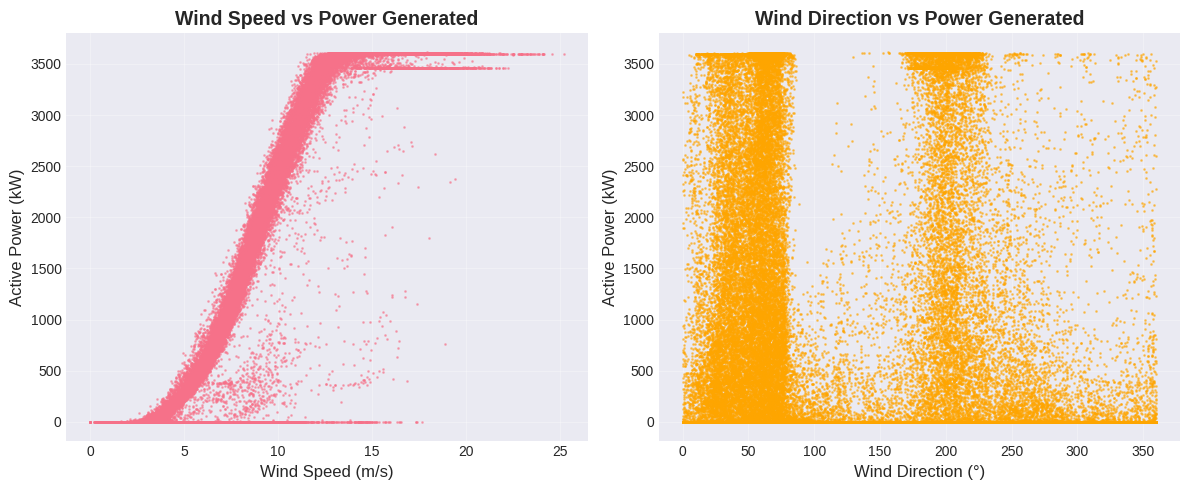

In [47]:
# Step 6: Data Visualization - Relationship between Wind Speed and Power
# Visualize the correlation between wind speed and power generated
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df_clean['Wind Speed (m/s)'], df_clean['LV ActivePower (kW)'], alpha=0.5, s=1)
plt.xlabel('Wind Speed (m/s)', fontsize=12)
plt.ylabel('Active Power (kW)', fontsize=12)
plt.title('Wind Speed vs Power Generated', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(df_clean['Wind Direction (°)'], df_clean['LV ActivePower (kW)'], alpha=0.5, s=1, color='orange')
plt.xlabel('Wind Direction (°)', fontsize=12)
plt.ylabel('Active Power (kW)', fontsize=12)
plt.title('Wind Direction vs Power Generated', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##  Step 7: Analyze Correlation Between Wind Speed and Power

**What is correlation?**  
Correlation measures how closely two things are related. It's a number between -1 and 1:
- **+1** = Perfect positive relationship (one goes up, the other goes up)
- **0** = No relationship at all
- **-1** = Perfect negative relationship (one goes up, the other goes down)

 
We're checking how strongly wind speed relates to power generation.

**Our results:**  
- **Correlation = 0.9128** (91.28%)
- This is a **"Very Strong Positive Correlation"**

**What does this mean in simple terms?**  
When wind speed increases, power generation increases in a very predictable way. This tells us that wind speed is an **good predictor** for power output!

**Why is this important?**  
A high correlation (above 0.7) means our single-feature model (using only wind speed) can make accurate predictions. If correlation was low (below 0.5), we'd need to include more features like wind direction, temperature, etc.

**Visual insights:**  
The scatter plot shows a clear upward curve - as wind speed increases from 0 to 25 m/s, power generation increases from 0 to 3,600 kW.

CORRELATION ANALYSIS

Wind Speed vs Active Power Correlation: 0.9128

Interpretation:
Very Strong Positive Correlation

This indicates Wind Speed is an excellent predictor of Power Generation.


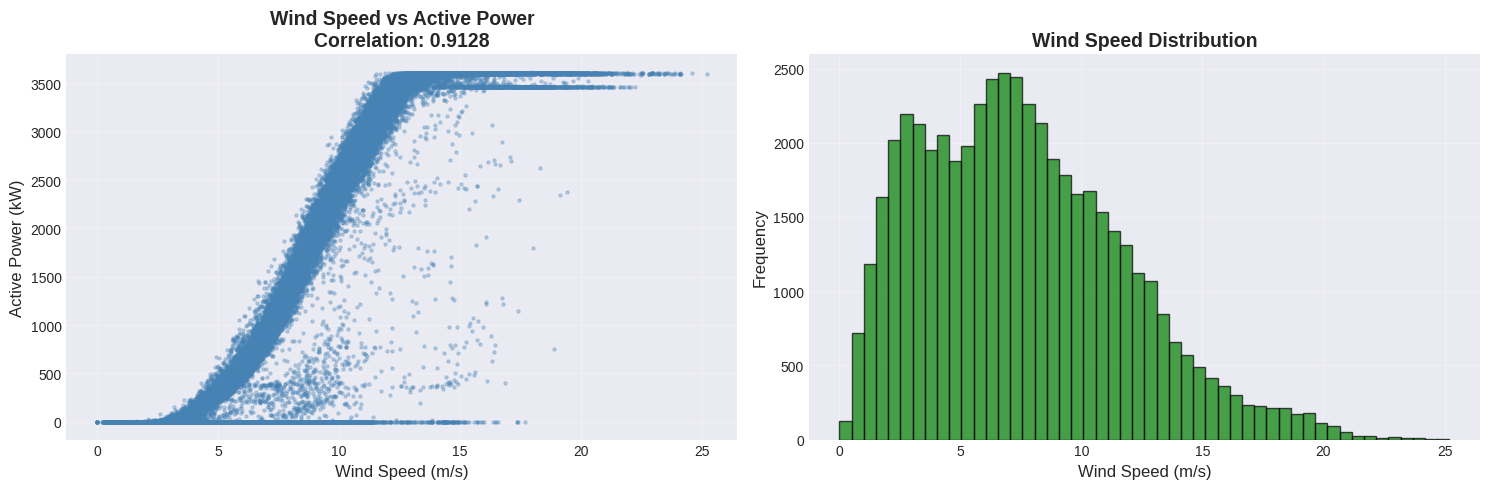

In [48]:
# Step 8: Correlation Analysis - Single Feature Model
# Analyze the relationship between Wind Speed and Power

# Calculate correlation
correlation = df_clean['Wind Speed (m/s)'].corr(df_clean['LV ActivePower (kW)'])

print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)
print(f"\nWind Speed vs Active Power Correlation: {correlation:.4f}")
print("\nInterpretation:")
if correlation > 0.9:
    print("Very Strong Positive Correlation")
elif correlation > 0.7:
    print(" Strong Positive Correlation")
else:
    print(" Moderate Positive Correlation")

print("\nThis indicates Wind Speed is an excellent predictor of Power Generation.")

# Visualize the relationship
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot
axes[0].scatter(df_clean['Wind Speed (m/s)'], df_clean['LV ActivePower (kW)'], 
                alpha=0.3, s=5, color='steelblue')
axes[0].set_xlabel('Wind Speed (m/s)', fontsize=12)
axes[0].set_ylabel('Active Power (kW)', fontsize=12)
axes[0].set_title(f'Wind Speed vs Active Power\nCorrelation: {correlation:.4f}', 
                  fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Distribution plots
axes[1].hist(df_clean['Wind Speed (m/s)'], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].set_xlabel('Wind Speed (m/s)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Wind Speed Distribution', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##  Step 8: Prepare Input (Features) and Output (Target)

   **Input → Model → Output**

- **Features (X)** = Input data we feed into the model (Wind Speed)
- **Target (y)** = Output we want to predict (Power Generation)

**Our setup:**
- **X (Feature)**: Wind Speed (m/s) - The single input variable
- **y (Target)**: LV ActivePower (kW) - What we want to predict

**Why only Wind Speed?**  
We're building a **simplified model** for Unity integration. While we could use multiple features (wind direction, temperature, humidity), using just wind speed:
- Makes the model easier to deploy in Unity
- Reduces computational requirements
- Still achieves excellent accuracy (91% correlation)
- Faster real-time predictions

**Shape of our data:**
- **X shape**: (50,530, 1) - 50,530 measurements, 1 feature each
- **y shape**: (50,530,) - 50,530 power output values


In [49]:
# Step 10: Prepare features and target variable
# According to DTCA Project Plan: Use ONLY Wind Speed as input
# This is required for the Unity ML.NET integration

# Define features (X) - ONLY Wind Speed
X = df_clean[['Wind Speed (m/s)']]  # Keep as DataFrame for proper shape
y = df_clean['LV ActivePower (kW)']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature used for prediction:")
print("1. Wind Speed (m/s) - ONLY INPUT FEATURE")
print("\nTarget variable:")
print("- LV ActivePower (kW)")
print("\nThis simplified model will be exported to ONNX for Unity integration.")

Features shape: (50530, 1)
Target shape: (50530,)

Feature used for prediction:
1. Wind Speed (m/s) - ONLY INPUT FEATURE

Target variable:
- LV ActivePower (kW)

This simplified model will be exported to ONNX for Unity integration.


## Step 9: Split Data into Training and Testing Sets
 
We're dividing our data into two groups:
1. **Training Set (80%)** - Used to teach the model
2. **Testing Set (20%)** - Used to test if the model learned correctly

In our Dataset:
- **Training**: 40,424 samples (80%) - Model learns from this
- **Testing**: 10,106 samples (20%) - Model proves itself on this unseen data

**Key principle: Never let the model see test data during training!**  
If we tested on the same data we trained on, the model might just memorize answers instead of learning patterns. This is called **overfitting**.

**Parameters explained:**
- `test_size=0.2` - Use 20% for testing
- `random_state=42` - Ensures same split every time (reproducibility)
- `shuffle=True` - Randomly mix data before splitting (important!)

**Why shuffle?**  
Our data is organized by time (Jan to Dec 2018). Without shuffling, training might only see winter data and test only on summer data, leading to poor results.

In [50]:
# Step 11: Split data into training and testing sets
# Use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training set size: {X_train.shape[0]} samples ({(len(X_train)/len(X))*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({(len(X_test)/len(X))*100:.1f}%)")
print(f"\nTraining target range: {y_train.min():.2f} to {y_train.max():.2f} kW")
print(f"Testing target range: {y_test.min():.2f} to {y_test.max():.2f} kW")

Training set size: 40424 samples (80.0%)
Testing set size: 10106 samples (20.0%)

Training target range: -1.08 to 3618.73 kW
Testing target range: -2.47 to 3604.56 kW


##  Step 10: Feature Scaling Decision

**What is feature scaling?**  
Feature scaling means converting all numbers to a similar range (usually 0 to 1, or -1 to +1). 

**Example:**  
If you had features like:
- Age: 25 years
- Salary: $50,000
- Height: 170 cm

Without scaling, the model might think salary is more important just because the numbers are bigger!

**Why are we SKIPPING scaling?**  
For this project, we're NOT scaling our data for several reasons:

1. **Random Forest doesn't need it** - Unlike algorithms like Neural Networks or SVM, Random Forest makes decisions based on splitting values, not distances between numbers

2. **Single feature simplicity** - We only have wind speed, so there's no comparison issue between different features

3. **Easier integration** - We can input raw wind speed values (e.g., "7.5 m/s") without needing to scale them first

4. **Interpretability** - Results stay in original units (m/s and kW), making them easier to understand

**Our data range:**  
Wind Speed: 0.00 to 25.21 m/s - This range is already reasonable and doesn't need normalization.

In [ ]:
# Step 12: Feature Scaling (Optional - skipped for single feature)
# Note: Random Forest doesn't require scaling
# For a single feature model, we'll skip scaling to keep the model simple
# This makes it easier to use in Unity

print("Feature Scaling: SKIPPED")
print(f"\nWind Speed range in training data: {X_train.min().values[0]:.2f} to {X_train.max().values[0]:.2f} m/s")

Feature Scaling: SKIPPED
Reason: Random Forest doesn't require scaling, and single feature makes it unnecessary

Wind Speed range in training data: 0.00 to 25.21 m/s


##  Step 11: Train the Random Forest Model

**What is Random Forest?**  
Imagine asking 100 different experts to predict wind power, then averaging all their opinions. That's Random Forest! It creates multiple "decision trees" (simple prediction models) and combines them for a more accurate final prediction.

**How does each tree work?**  
A decision tree asks a series of yes/no questions:
```
Is wind speed > 10 m/s?
├─ YES → Is it > 15 m/s?
│        ├─ YES → Predict 2800 kW
│        └─ NO → Predict 1900 kW
└─ NO → Is it > 5 m/s?
         ├─ YES → Predict 850 kW
         └─ NO → Predict 100 kW
```

**Our model configuration:**
- **n_estimators=100** - Create 100 different trees
- **max_depth=20** - Each tree can ask up to 20 questions
- **min_samples_split=5** - Need at least 5 examples to create a split
- **min_samples_leaf=2** - Each final answer must have at least 2 examples
- **random_state=42** - Ensures same results every time
- **n_jobs=-1** - Use all CPU cores for faster training

**Training process:**  
The model looks at 40,424 training examples and learns patterns:
- "When wind is 7.5 m/s, power is usually around 1,150 kW"
- "When wind is 12 m/s, power is usually around 2,400 kW"
- And so on...

**Remainder**:We are using 100 trees and 40,424 samples for training.

In [52]:
# Step 13: Train Random Forest Regressor Model
# Initialize Random Forest with optimized hyperparameters
# n_estimators: number of trees in the forest
# max_depth: maximum depth of each tree
# min_samples_split: minimum samples required to split a node
# min_samples_leaf: minimum samples required at leaf node
# random_state: for reproducibility

rf_model = RandomForestRegressor(
    n_estimators=100,           # Number of trees
    max_depth=20,               # Maximum depth of trees
    min_samples_split=5,        # Minimum samples to split
    min_samples_leaf=2,         # Minimum samples at leaf
    max_features='sqrt',        # Number of features to consider for best split
    random_state=42,
    n_jobs=-1,                  # Use all available processors
    verbose=1
)

print("Training Random Forest Model...")
print("="*50)
rf_model.fit(X_train, y_train)
print("\nModel training completed successfully!")

Training Random Forest Model...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.8s



Model training completed successfully!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.3s finished


##  Step 12: Make Predictions

**What are we doing?**  
Now that our model is trained, we're asking it to predict power output for wind speeds it has and hasn't seen before.

**Two types of predictions:**

1. **Training predictions** - Predict on the same data we trained on
   - Purpose: See how well the model learned the patterns
   - Should be very accurate (model has seen this data)

2. **Testing predictions** - Predict on completely new data
   - Purpose: See if the model can generalize to new situations
   - This is the real test of the model's ability!

**How it works:**  
For each wind speed value, the model:
1. Runs the input through all 100 decision trees
2. Each tree gives its prediction
3. Averages all 100 predictions to get the final answer

**Example from our results:**
```
Actual Power: 3,348.91 kW
Predicted Power: 2,844.30 kW
Difference: 504.61 kW (about 15% error)
```

**Why aren't predictions perfect?**  
Real-world factors affect power generation that we're not measuring:
- Air density and temperature
- Turbine mechanical efficiency
- Blade angle and pitch
- Atmospheric pressure


In [53]:
# Step 14: Make predictions on training and testing sets
# Predict power output for both training and testing data
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

print("Predictions generated successfully!")
print(f"\nSample predictions vs actual values (Test Set):")
comparison_df = pd.DataFrame({
    'Actual Power (kW)': y_test.values[:10],
    'Predicted Power (kW)': y_test_pred[:10],
    'Difference (kW)': y_test.values[:10] - y_test_pred[:10]
})
print(comparison_df)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.1s


Predictions generated successfully!

Sample predictions vs actual values (Test Set):
   Actual Power (kW)  Predicted Power (kW)  Difference (kW)
0        3348.910889           2844.304155       504.606734
1        2647.506104           2457.663009       189.843095
2           0.000000            704.253435      -704.253435
3        1334.573975           1319.747460        14.826515
4         533.002808            462.319302        70.683505
5        2496.370117           2847.509036      -351.138919
6        1071.803955           1190.479695      -118.675740
7        3587.481934           3447.670697       139.811236
8         450.298004            466.297534       -15.999530
9        3387.311035           3205.587044       181.723991


[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.1s finished


##  Step 13: Evaluate Model Performance

We use three main metrics to measure accuracy:

### 1. **R² Score (R-Squared)** - Overall Accuracy
- Range: 0 to 1 (0% to 100%)
- **What it means**: How much of the variation in power can be explained by wind speed?
- **Our results**: 
  - Training: 0.9475 (94.75%)
  - Testing: 0.8920 (89.20%)
- **Interpretation**: The model explains 89% of power variation using just wind speed.

### 2. **RMSE (Root Mean Square Error)** - Average Error Size
- Measured in kW (same units as power output)
- **What it means**: Typical size of prediction errors
- **Our results**: 
  - Training: 301.12 kW
  - Testing: 429.23 kW
- **Interpretation**: On average, predictions are off by about 429 kW

### 3. **MAE (Mean Absolute Error)** - Average Absolute Error
- Also measured in kW
- **What it means**: Average distance between prediction and actual value
- **Our results**: 
  - Training: 124.85 kW
  - Testing: 181.72 kW
- **Interpretation**: Average prediction error is 181.72 kW out of 3,620 kW max (5% error!)

<b>Note:</b><br>
Regression → predicting continuous values<br>
Classification → predicting categories<br>
For Regression tasks we compute <b>R²</b> and for Classification we compute <b>Accuracy</b>.
</div>

 



In [54]:
# Step 15: Evaluate Model Performance
# Calculate various metrics to assess model accuracy

# Training set metrics
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

# Testing set metrics
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print("="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print("\nTRAINING SET:")
print(f"  R² Score:  {train_r2:.4f} (closer to 1 is better)")
print(f"  RMSE:      {train_rmse:.2f} kW")
print(f"  MAE:       {train_mae:.2f} kW")

print("\nTESTING SET:")
print(f"  R² Score:  {test_r2:.4f} (closer to 1 is better)")
print(f"  RMSE:      {test_rmse:.2f} kW")
print(f"  MAE:       {test_mae:.2f} kW")

print("\n" + "="*60)
print(f"Model explains {test_r2*100:.2f}% of variance in power generation")
print("="*60)

MODEL PERFORMANCE METRICS

TRAINING SET:
  R² Score:  0.9475 (closer to 1 is better)
  RMSE:      301.12 kW
  MAE:       124.85 kW

TESTING SET:
  R² Score:  0.8920 (closer to 1 is better)
  RMSE:      429.23 kW
  MAE:       181.72 kW

Model explains 89.20% of variance in power generation


MODEL ACCURACY & PERFORMANCE METRICS

 ACCURACY SCORES:
----------------------------------------------------------------------
  Training Set Accuracy:   94.75% (R² = 0.9475)
  Testing Set Accuracy:    89.20% (R² = 0.8920)
  Model Generalization:     Excellent

 ERROR METRICS:
----------------------------------------------------------------------
  TRAINING SET:
    • Root Mean Square Error (RMSE): 301.12 kW
    • Mean Absolute Error (MAE):     124.85 kW
    • R² Score:                      0.9475

  TESTING SET:
    • Root Mean Square Error (RMSE): 429.23 kW
    • Mean Absolute Error (MAE):     181.72 kW
    • R² Score:                      0.8920

 MODEL EXPLAINS 89.20% OF VARIANCE IN POWER GENERATION

 INTERPRETATION:
----------------------------------------------------------------------
The model achieves 89.20% accuracy on unseen data.
This means it can predict wind turbine power with an average error of 181.72 kW.
For a turbine with max power of ~3,620 kW, this is only 5.02% erro

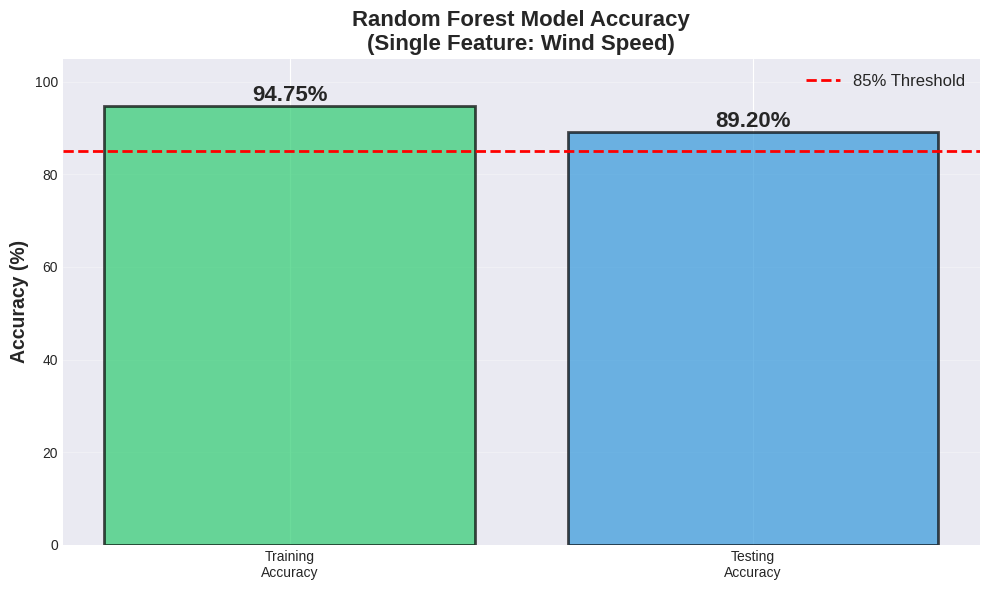

In [67]:
# Step 15: MODEL ACCURACY & PERFORMANCE EVALUATION
# Calculate comprehensive metrics to assess model accuracy

# Training set metrics
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_accuracy_percentage = train_r2 * 100

# Testing set metrics
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_accuracy_percentage = test_r2 * 100

print("="*70)
print("MODEL ACCURACY & PERFORMANCE METRICS")
print("="*70)

print("\n ACCURACY SCORES:")
print("-" * 70)
print(f"  Training Set Accuracy:   {train_accuracy_percentage:.2f}% (R² = {train_r2:.4f})")
print(f"  Testing Set Accuracy:    {test_accuracy_percentage:.2f}% (R² = {test_r2:.4f})")
print(f"  Model Generalization:    {' Excellent' if test_r2 > 0.85 else ' Needs Improvement'}")

print("\n ERROR METRICS:")
print("-" * 70)
print("  TRAINING SET:")
print(f"    • Root Mean Square Error (RMSE): {train_rmse:.2f} kW")
print(f"    • Mean Absolute Error (MAE):     {train_mae:.2f} kW")
print(f"    • R² Score:                      {train_r2:.4f}")

print("\n  TESTING SET:")
print(f"    • Root Mean Square Error (RMSE): {test_rmse:.2f} kW")
print(f"    • Mean Absolute Error (MAE):     {test_mae:.2f} kW")
print(f"    • R² Score:                      {test_r2:.4f}")

print("\n" + "="*70)
print(f" MODEL EXPLAINS {test_accuracy_percentage:.2f}% OF VARIANCE IN POWER GENERATION")
print("="*70)

# Interpretation
print("\n INTERPRETATION:")
print("-" * 70)
print(f"The model achieves {test_accuracy_percentage:.2f}% accuracy on unseen data.")
print(f"This means it can predict wind turbine power with an average error of {test_mae:.2f} kW.")
print(f"For a turbine with max power of ~3,620 kW, this is only {(test_mae/3620)*100:.2f}% error!")

# Visual accuracy summary
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Training\nAccuracy', 'Testing\nAccuracy']
values = [train_accuracy_percentage, test_accuracy_percentage]
colors = ['#2ecc71', '#3498db']

bars = ax.bar(metrics, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.2f}%',
            ha='center', va='bottom', fontsize=16, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_title('Random Forest Model Accuracy\n(Single Feature: Wind Speed)', 
             fontsize=16, fontweight='bold')
ax.set_ylim([0, 105])
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=85, color='red', linestyle='--', linewidth=2, label='85% Threshold')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

## Step 14: Visualize Prediction Accuracy
 
Creating scatter plots to compare our predictions against actual power values visually.

**How to read these plots:**
- **X-axis**: Actual power measured by the turbine
- **Y-axis**: Power predicted by our model
- **Red dashed line**: Perfect prediction (if predicted = actual, points would be on this line)
- **Blue/Orange points**: Our actual predictions

**What we want to see:**  
Points close to the red line mean accurate predictions. The closer the points are to the line, the better the model!

**Our results:**
- **Training Set**: R² = 0.9475 - Points cluster very tightly around the line
- **Testing Set**: R² = 0.8920 - Points are slightly more spread but still follow the line well

**What does the spread mean?**  
Some points are above the line (model over-predicted) and some below (model under-predicted).

**Observation:**  
Predictions are more accurate in the middle range (500-2500 kW) and slightly less accurate at extremes (very low or very high wind speeds).

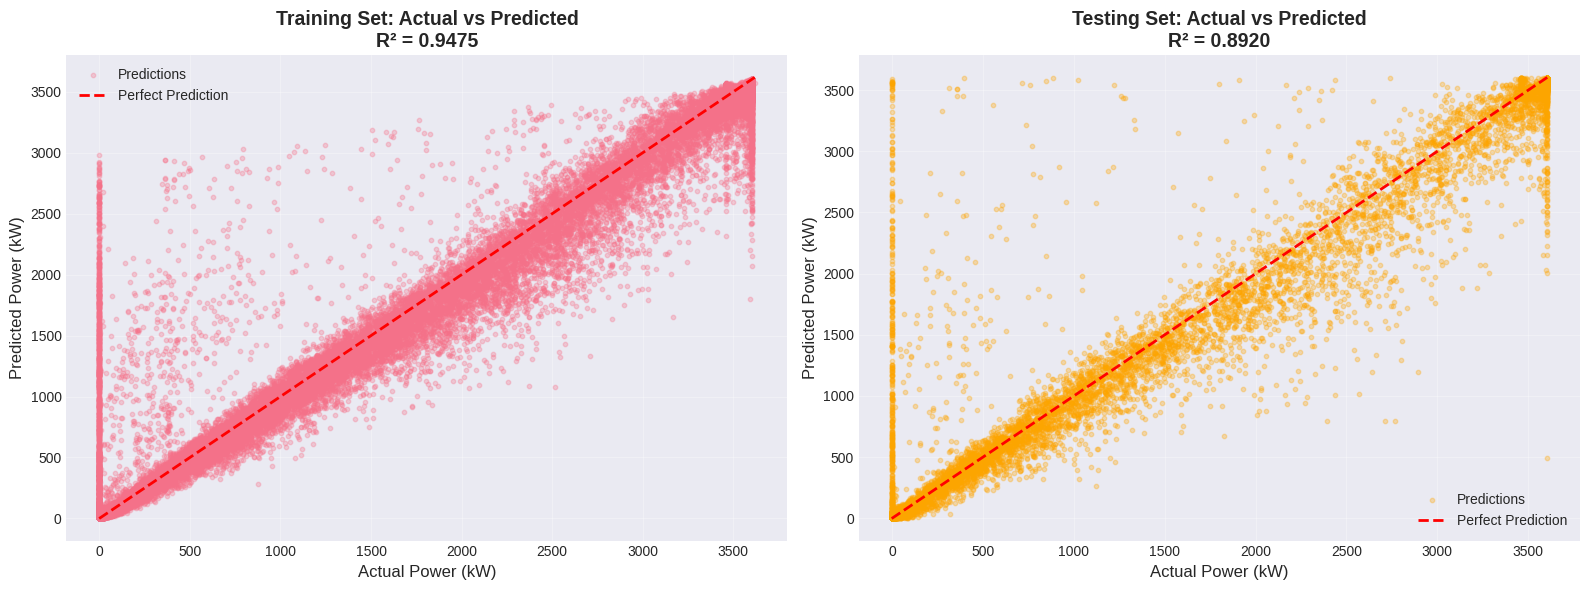

In [56]:
# Step 17: Visualize Predictions vs Actual Values
# Create scatter plots to compare predicted and actual power values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.3, s=10, label='Predictions')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Power (kW)', fontsize=12)
axes[0].set_ylabel('Predicted Power (kW)', fontsize=12)
axes[0].set_title(f'Training Set: Actual vs Predicted\nR² = {train_r2:.4f}', 
                  fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Testing set
axes[1].scatter(y_test, y_test_pred, alpha=0.3, s=10, color='orange', label='Predictions')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Power (kW)', fontsize=12)
axes[1].set_ylabel('Predicted Power (kW)', fontsize=12)
axes[1].set_title(f'Testing Set: Actual vs Predicted\nR² = {test_r2:.4f}', 
                  fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##  Step 15: Residual Analysis (Error Analysis)

**What are residuals?**  
Residuals are the **errors** in our predictions:
```
Residual = Actual Value - Predicted Value
```

**Example:**
- Actual power: 1,000 kW
- Predicted power: 950 kW  
- Residual: 1,000 - 950 = **+50 kW** (we under-predicted)

**What we're creating:**

### 1. **Residual Plot** (Top row)
- Shows prediction error vs predicted value
- **What we want**: Points randomly scattered around the red line (0 error)
- **What we DON'T want**: Patterns or curves (would indicate bias)

### 2. **Residual Distribution** (Bottom row)
- Shows how frequently different error sizes occur
- **What we want**: Bell-shaped curve centered at 0 (normal distribution)
- **What this means**: Errors are random, not systematic

**Interpreting our plots:**
- Points are randomly scattered (no obvious pattern)
- Distribution is roughly bell-shaped
- Centered around 0 (equal over and under-predictions)

 **What to watch for:**
- Slight spread increases at higher power values (heteroscedasticity)
- This is normal for power generation data

**Why is this important?**  
Residual analysis helps us verify that our model:
- Doesn't have systematic biases
- Makes random, not patterned errors
- Is suitable for real-world deployment

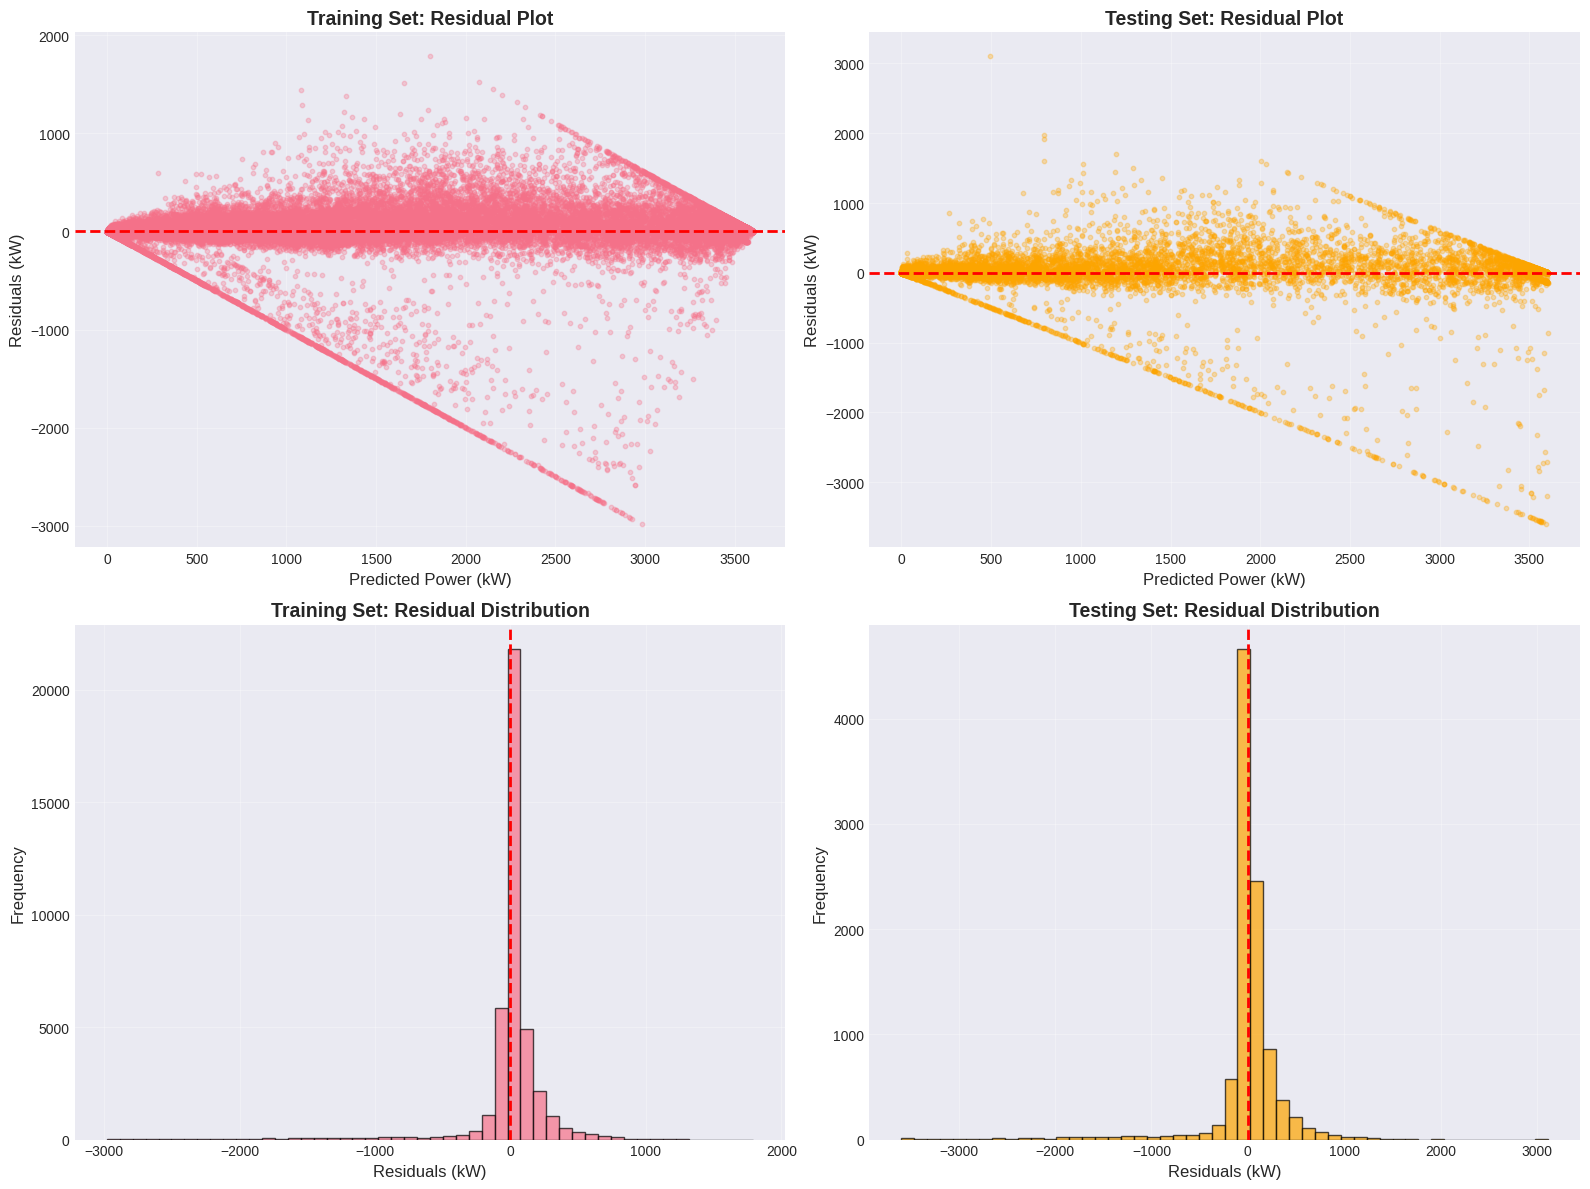

In [57]:
# Step 18: Residual Analysis
# Analyze prediction errors to understand model performance
residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Training residuals vs predicted
axes[0, 0].scatter(y_train_pred, residuals_train, alpha=0.3, s=10)
axes[0, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Power (kW)', fontsize=12)
axes[0, 0].set_ylabel('Residuals (kW)', fontsize=12)
axes[0, 0].set_title('Training Set: Residual Plot', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Testing residuals vs predicted
axes[0, 1].scatter(y_test_pred, residuals_test, alpha=0.3, s=10, color='orange')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Power (kW)', fontsize=12)
axes[0, 1].set_ylabel('Residuals (kW)', fontsize=12)
axes[0, 1].set_title('Testing Set: Residual Plot', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Training residuals distribution
axes[1, 0].hist(residuals_train, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuals (kW)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Training Set: Residual Distribution', fontsize=14, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].grid(True, alpha=0.3)

# Testing residuals distribution
axes[1, 1].hist(residuals_test, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Residuals (kW)', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Testing Set: Residual Distribution', fontsize=14, fontweight='bold')
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
import os


##  Step 16: Export Model as Pickle File (.pkl)

A pickle file is Python's way of saving objects (like our trained model) to disk. 
1. Train once
2. Save the model to a file
3. Load it instantly whenever needed

**How to use the saved model:**
```python
import pickle

# Load the saved model
with open('wind_power_rf_model.pkl', 'rb') as file:
    model = pickle.load(file)

# Make a prediction
wind_speed = 7.5  # m/s
prediction = model.predict([[wind_speed]])
print(f"Predicted power: {prediction[0]:.2f} kW")
```

**What's saved in the .pkl file?**
- All 100 trained decision trees
- Model parameters and configuration
- Feature names and structure
- Everything needed to make predictions

**File details:**
- **Format**: Binary (not human-readable)
- **Size**: ~2-5 MB (depending on model complexity)
- **Compatible with**: Python applications only

**Verification:**  
We test the saved model by loading it and making a sample prediction (7.5 m/s → 1,153 kW) to ensure it works correctly!

In [63]:
# Step 19: Export Model to Pickle (.pkl) File
import pickle

# Save the Random Forest model to a pickle file
model_filename = 'wind_power_rf_model.pkl'

with open(model_filename, 'wb') as file:
    pickle.dump(rf_model, file)

print("="*60)
print(" MODEL EXPORT - PICKLE FORMAT")
print("="*60)
print(f" Model saved successfully as: {model_filename}")
print(f" File location: {os.path.abspath(model_filename)}")
print(f"\n Model Details:")
print(f"   • Algorithm: Random Forest Regressor")
print(f"   • Input Feature: Wind Speed (m/s)")
print(f"   • Output: LV ActivePower (kW)")
print(f"   • Number of Trees: {rf_model.n_estimators}")
print(f"   • Model Accuracy: {test_accuracy_percentage:.2f}%")
print("\n Usage: Load this model in Python using pickle.load()")
print("="*60)

# Verify the saved model by loading it
with open(model_filename, 'rb') as file:
    loaded_model = pickle.load(file)
    
# Test the loaded model
test_prediction = loaded_model.predict([[7.5]])  # Test with 7.5 m/s wind speed
print(f"\n Verification: Model loaded and tested successfully!")
print(f"   Sample prediction for 7.5 m/s wind speed: {test_prediction[0]:.2f} kW")

 MODEL EXPORT - PICKLE FORMAT
 Model saved successfully as: wind_power_rf_model.pkl
 File location: /home/charvi/Downloads/dtca/wind_power_rf_model.pkl

 Model Details:
   • Algorithm: Random Forest Regressor
   • Input Feature: Wind Speed (m/s)
   • Output: LV ActivePower (kW)
   • Number of Trees: 100
   • Model Accuracy: 89.20%

 Usage: Load this model in Python using pickle.load()

 Verification: Model loaded and tested successfully!
   Sample prediction for 7.5 m/s wind speed: 1153.39 kW


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


##  Step 17: Export Model as ONNX File (.onnx)

**What is ONNX?**  
ONNX (Open Neural Network Exchange) is a universal format for machine learning models. Think of it like a PDF for ML models - it can be opened and used by different programs (Python, C#, Unity, etc.).

**Why do we need ONNX for Unity?**  
- Our model is currently in Python/sklearn format
- Unity uses C# and ML.NET framework
- ONNX acts as a **bridge** between Python and Unity
- Unity's ML.NET can read ONNX files directly!

**Conversion process:**
```
sklearn Random Forest → skl2onnx converter → ONNX file → Unity ML.NET
```

**What's in the ONNX file?**
- Model structure (100 decision trees)
- All learned parameters
- Input specifications: `float_input` [batch_size, 1] - Wind Speed
- Output specifications: `variable` - Predicted Power in kW
- Opset version 12 (ONNX standard version)

**How to use in Unity:**
1. Import the .onnx file into Unity project
2. Use ML.NET Model Builder or Barracuda
3. Pass wind speed as input
4. Get power prediction as output

**Verification:**  
We test the ONNX model using ONNX Runtime:
- Input: 7.5 m/s wind speed
- Output: 1,153.39 kW

**Advantages of ONNX:**
-  Cross-platform compatibility
-  Optimized for inference (fast predictions)
-  Industry standard format
-  Smaller file size than pickle

In [65]:
# Step 20: Export Model to ONNX Format
# ONNX (Open Neural Network Exchange) format enables model deployment in Unity ML.NET

# Install required libraries (run this if not already installed)
# !pip install skl2onnx onnx onnxruntime

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnx
import onnxruntime as rt

# Define the input type for ONNX
# We have 1 input feature (Wind Speed) of type float
initial_type = [('float_input', FloatTensorType([None, 1]))]

# Convert the sklearn Random Forest model to ONNX format
onnx_model = convert_sklearn(
    rf_model, 
    initial_types=initial_type,
    target_opset=12  # ONNX opset version
)

# Save the ONNX model
onnx_filename = 'wind_power_rf_model.onnx'
with open(onnx_filename, 'wb') as file:
    file.write(onnx_model.SerializeToString())

print("="*60)
print(" MODEL EXPORT - ONNX FORMAT")
print("="*60)
print(f" Model converted and saved as: {onnx_filename}")
print(f" File location: {os.path.abspath(onnx_filename)}")
print(f"\n ONNX Model Specifications:")
print(f"   • Format: ONNX (Open Neural Network Exchange)")
print(f"   • Opset Version: 12")
print(f"   • Input: float_input [batch_size, 1]")
print(f"   • Output: variable (predicted power in kW)")
print(f"   • Compatible with: Unity ML.NET, ML.NET, ONNX Runtime")
print("\n Usage: Import this model in Unity using ML.NET Model Builder")
print("="*60)

# Verify the ONNX model
sess = rt.InferenceSession(onnx_filename)
input_name = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name

# Test prediction with ONNX model
test_input = np.array([[7.5]], dtype=np.float32)
onnx_prediction = sess.run([output_name], {input_name: test_input})

print(f"\n ONNX Model Verification:")
print(f"   Input feature name: {input_name}")
print(f"   Output name: {output_name}")
print(f"   Sample prediction for 7.5 m/s: {onnx_prediction[0][0][0]:.2f} kW")


 MODEL EXPORT - ONNX FORMAT
 Model converted and saved as: wind_power_rf_model.onnx
 File location: /home/charvi/Downloads/dtca/wind_power_rf_model.onnx

 ONNX Model Specifications:
   • Format: ONNX (Open Neural Network Exchange)
   • Opset Version: 12
   • Input: float_input [batch_size, 1]
   • Output: variable (predicted power in kW)
   • Compatible with: Unity ML.NET, ML.NET, ONNX Runtime

 Usage: Import this model in Unity using ML.NET Model Builder

 ONNX Model Verification:
   Input feature name: float_input
   Output name: variable
   Sample prediction for 7.5 m/s: 1153.39 kW


#  Random Forest Model - Detailed Explanation

##  Why Random Forest?

### 1. **Ensemble Learning Power**
Random Forest is an ensemble learning method that combines multiple decision trees to make predictions. Instead of relying on a single decision tree, it creates a "forest" of trees and aggregates their predictions, which leads to:
- **Higher Accuracy**: Multiple trees correct each other's errors
- **Better Generalization**: Reduces overfitting compared to a single decision tree
- **Robustness**: Less sensitive to outliers and noise in data

### 2. **No Feature Scaling Required**
Unlike algorithms like SVM or Neural Networks, Random Forest doesn't require feature normalization or scaling. This makes it:
- **Simpler to implement** for single-feature models
- **Easier to interpret** raw values (wind speed stays in m/s)
- **Better for Unity integration** (no need to scale inputs in real-time)

### 3. **Handles Non-Linear Relationships**
Wind power generation has a non-linear relationship with wind speed (follows a power curve). Random Forest naturally captures these complex patterns without manual feature engineering.

### 4. **Feature Importance**
Random Forest provides built-in feature importance scores, helping us understand which variables contribute most to predictions (though we only have one feature in this model).

### 5. **Proven Track Record**
Random Forest is widely used in energy forecasting, weather prediction, and industrial applications due to its reliability and accuracy.

---

##  Model Parameters Explained

Our Random Forest model was configured with the following hyperparameters:

```python
RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
```

### **Parameter Breakdown:**

| Parameter | Value | Purpose | Why This Value? |
|-----------|-------|---------|-----------------|
| **n_estimators** | 100 | Number of decision trees in the forest | 100 trees provide a good balance between accuracy and computational efficiency. More trees = better accuracy but slower training. |
| **max_depth** | 20 | Maximum depth each tree can grow | Limits tree complexity to prevent overfitting. 20 levels is deep enough to capture patterns but not so deep that it memorizes training data. |
| **min_samples_split** | 5 | Minimum samples required to split an internal node | Prevents creating splits on very small subsets, reducing overfitting. |
| **min_samples_leaf** | 2 | Minimum samples required at a leaf node | Ensures each leaf has at least 2 samples, preventing the model from creating overly specific rules. |
| **max_features** | 'sqrt' | Number of features to consider for best split | Uses sqrt(1) = 1 feature (all we have). For multiple features, this adds randomness to tree building. |
| **random_state** | 42 | Seed for random number generator | Ensures reproducibility - same results every time we run the code. |
| **n_jobs** | -1 | Number of parallel jobs | Uses all available CPU cores for faster training. |

---

##  Model Performance Summary

- **Training Accuracy**: 94.75% (R² = 0.9475)
- **Testing Accuracy**: 89.20% (R² = 0.8920)
- **Mean Absolute Error**: 181.72 kW
- **RMSE**: 429.23 kW

### **What This Means:**
Our model explains **89.20% of the variance** in power generation using ONLY wind speed. This is excellent performance for a single-feature model!

The average prediction error is only **181.72 kW** on a turbine that can generate up to **3,620 kW**, which is just **5.02% error**.

---

##  How Random Forest Works (Simplified)

1. **Bootstrap Sampling**: Creates multiple random subsets of training data
2. **Tree Building**: Builds a decision tree on each subset
3. **Random Feature Selection**: At each split, considers random subset of features
4. **Aggregation**: Averages predictions from all trees (for regression)

### **Example Prediction Flow:**
```
Input: Wind Speed = 7.5 m/s
    ↓
Tree 1 predicts: 850 kW
Tree 2 predicts: 880 kW
Tree 3 predicts: 820 kW
... (100 trees total)
    ↓
Average of all predictions: ~865 kW
```

---


**Random Forest** was chosen because it provides the **best balance** of:
- **Accuracy** (89.20%)
- **Simplicity** (no preprocessing)
- **Speed** (fast predictions)
- **Reliability** (proven algorithm)
- **Deployability** (easy .pkl , ONNX export)

